# Computational Simulation of Heat Transfer

This section models 1D heat conduction in a thin rod using the heat equation:

$$
\frac{\partial T}{\partial t} = \alpha \frac{\partial^2 T}{\partial x^2}
$$

where:
- $T(x,t)$ is temperature,
- $\alpha$ is thermal diffusivity,
- $x \in [0, L]$ and $t \ge 0$.

We solve this numerically with an explicit finite-difference method, apply fixed boundary temperatures, and visualize how heat diffuses over time.

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# --- Physical and numerical parameters ---
L = 1.0                 # rod length (m)
alpha = 1.2e-4          # thermal diffusivity (m^2/s), example material
nx = 101                # number of spatial grid points
x = np.linspace(0, L, nx)
dx = x[1] - x[0]

t_final = 30.0          # total simulation time (s)

# Explicit method stability condition: r = alpha*dt/dx^2 <= 0.5
dt = 0.35 * dx**2 / alpha
nt = int(np.ceil(t_final / dt))
dt = t_final / nt
r = alpha * dt / dx**2

print(f'dx = {dx:.5f}, dt = {dt:.5f}, r = {r:.4f}, nt = {nt}')
if r > 0.5:
    raise ValueError('Scheme is unstable. Reduce dt or increase dx.')

dx = 0.01000, dt = 0.29126, r = 0.3495, nt = 103


In [11]:
# --- Initial and boundary conditions ---
T_left = 100.0          # left boundary temperature (deg C)
T_right = 25.0          # right boundary temperature (deg C)

# Initial profile: cool rod with a warm Gaussian bump near the center
T = 25.0 + 50.0 * np.exp(-((x - 0.5 * L) ** 2) / (2 * (0.08 * L) ** 2))
T[0] = T_left
T[-1] = T_right

# Save snapshots for plotting
save_times = [0.0, 2.0, 5.0, 10.0, 20.0, 30.0]
snapshots = {0.0: T.copy()}

In [12]:
# --- Time stepping (explicit finite differences) ---
Tn = T.copy()
time_grid = np.linspace(0, t_final, nt + 1)

for n in range(1, nt + 1):
    T_new = Tn.copy()
    T_new[1:-1] = Tn[1:-1] + r * (Tn[2:] - 2.0 * Tn[1:-1] + Tn[:-2])

    # Dirichlet boundary conditions
    T_new[0] = T_left
    T_new[-1] = T_right

    Tn = T_new

    current_t = time_grid[n]
    for ts in save_times:
        if ts not in snapshots and abs(current_t - ts) <= dt / 2:
            snapshots[ts] = Tn.copy()

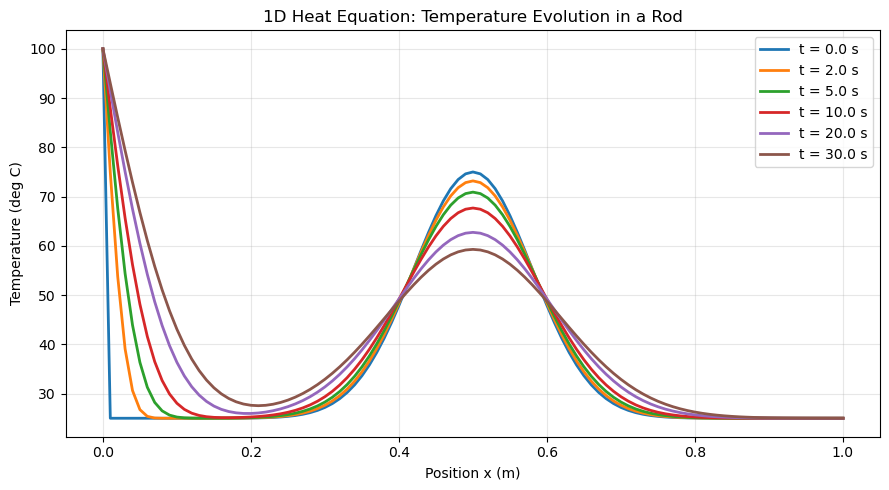

Final center temperature at x=L/2: 59.28 deg C


In [13]:
# --- Plot temperature profiles at selected times ---
plt.figure(figsize=(9, 5))
for ts in sorted(snapshots.keys()):
    plt.plot(x, snapshots[ts], label=f't = {ts:.1f} s', linewidth=2)

plt.title('1D Heat Equation: Temperature Evolution in a Rod')
plt.xlabel('Position x (m)')
plt.ylabel('Temperature (deg C)')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Final profile summary
print(f'Final center temperature at x=L/2: {Tn[nx//2]:.2f} deg C')

## Low vs High Diffusivity Materials (Reentry-Inspired Scenario)

To compare materials, we simulate an initial thermal hot spot (representing intense aerodynamic heating concentrated near a leading-edge region) and track how quickly heat spreads.

We compare:
- **Low diffusivity material**: heat spreads slowly.
- **High diffusivity material (RCC-like behavior)**: heat spreads quickly, reducing local peak temperatures and steep thermal gradients.

For reentry design, this can be desirable on leading edges because spreading heat can reduce hot-spot severity and thermal stress. (In full TPS design, the best choice also depends on insulation needs, thickness, emissivity, and structural constraints.)

In [14]:
def simulate_hotspot_diffusion(alpha_material, L=1.0, nx=201, t_final=120.0, T_ambient=300.0, probe_x=0.45):
    """Simulate 1D heat diffusion of an initial hotspot with fixed ambient boundaries."""
    x = np.linspace(0.0, L, nx)
    dx = x[1] - x[0]

    # Stability-safe time step for explicit scheme
    dt = 0.45 * dx**2 / alpha_material
    nt = int(np.ceil(t_final / dt))
    dt = t_final / nt
    r = alpha_material * dt / dx**2

    if r > 0.5:
        raise ValueError('Unstable setup encountered.')

    # Hotspot near leading-edge side (x ~ 0.15L)
    T = T_ambient + 1200.0 * np.exp(-((x - 0.15 * L) ** 2) / (2.0 * (0.05 * L) ** 2))
    T[0] = T_ambient
    T[-1] = T_ambient

    times = np.linspace(0.0, t_final, nt + 1)
    save_times = [0.0, 5.0, 10.0, 30.0, 60.0, 120.0]

    max_temp = np.zeros(nt + 1)
    probe_temp = np.zeros(nt + 1)
    probe_idx = int(probe_x * (nx - 1))

    max_temp[0] = np.max(T)
    probe_temp[0] = T[probe_idx]

    Tn = T.copy()
    history = [Tn.copy()]

    for n in range(1, nt + 1):
        Tnew = Tn.copy()
        Tnew[1:-1] = Tn[1:-1] + r * (Tn[2:] - 2.0 * Tn[1:-1] + Tn[:-2])
        Tnew[0] = T_ambient
        Tnew[-1] = T_ambient
        Tn = Tnew

        max_temp[n] = np.max(Tn)
        probe_temp[n] = Tn[probe_idx]
        history.append(Tn.copy())

    # Always provide requested snapshot times via nearest simulated time index
    snapshots = {}
    for ts in save_times:
        idx = int(np.argmin(np.abs(times - ts)))
        snapshots[ts] = history[idx]

    return {
        'x': x,
        'times': times,
        'snapshots': snapshots,
        'max_temp': max_temp,
        'probe_temp': probe_temp,
        'probe_x': probe_x,
        'alpha': alpha_material,
        'dt': dt,
        'r': r,
    }


# Example diffusivities (m^2/s)
alpha_low = 2.0e-6
alpha_high = 1.2e-4  # RCC-like high-diffusivity order of magnitude

low_case = simulate_hotspot_diffusion(alpha_low)
high_case = simulate_hotspot_diffusion(alpha_high)

print(f"Low diffusivity alpha = {alpha_low:.2e}, dt = {low_case['dt']:.3e}, r = {low_case['r']:.3f}")
print(f"High diffusivity alpha = {alpha_high:.2e}, dt = {high_case['dt']:.3e}, r = {high_case['r']:.3f}")

Low diffusivity alpha = 2.00e-06, dt = 5.455e+00, r = 0.436
High diffusivity alpha = 1.20e-04, dt = 9.375e-02, r = 0.450


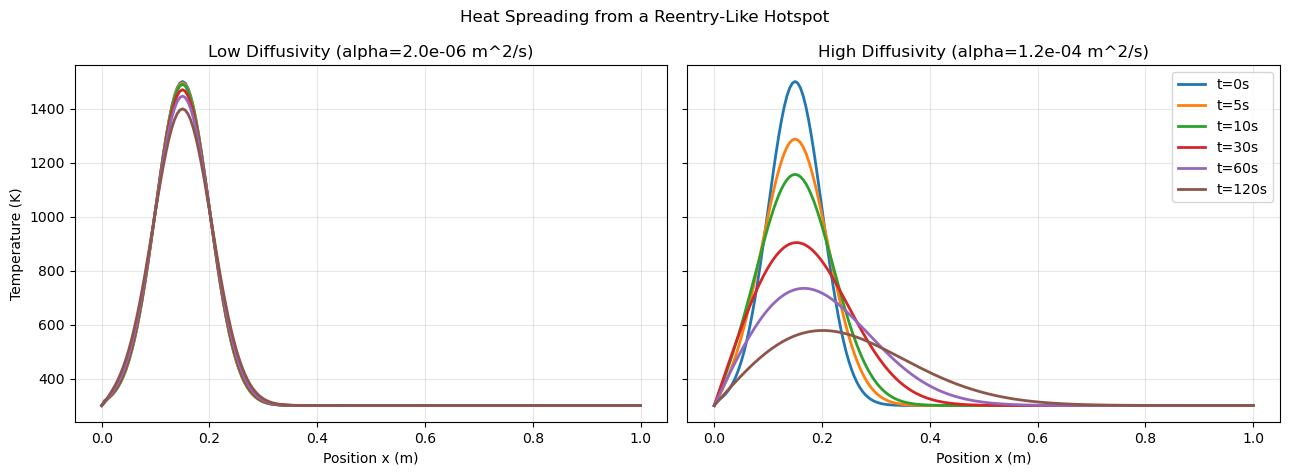

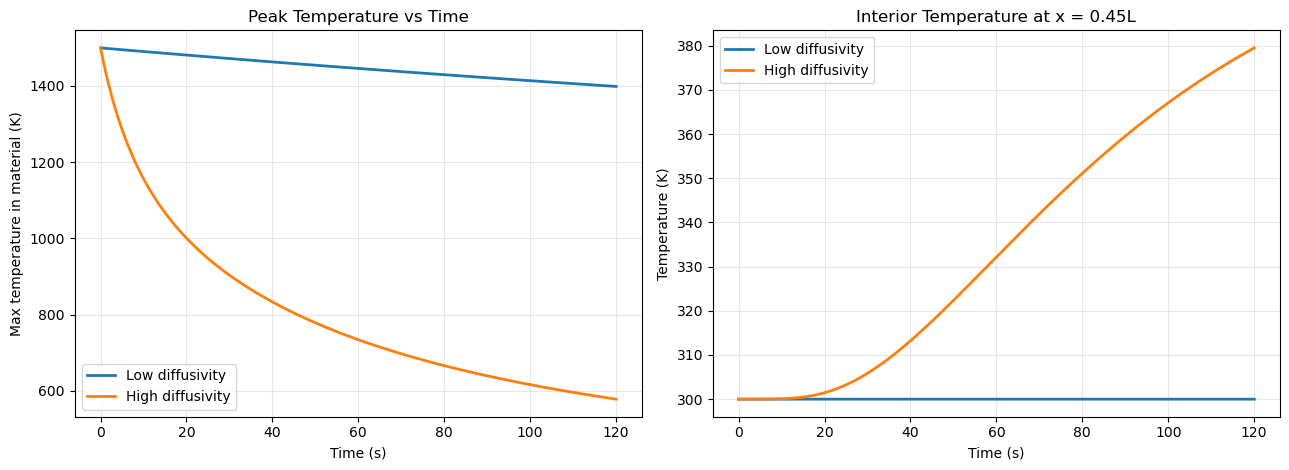

At t = 120 s:
  Low diffusivity max temp:  1398.81 K
  High diffusivity max temp: 577.93 K
  Low diffusivity T at x=0.45L:  300.00 K
  High diffusivity T at x=0.45L: 379.49 K


In [15]:
# --- Snapshot profiles: low vs high diffusivity ---
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), sharey=True)
plot_times = [0.0, 5.0, 10.0, 30.0, 60.0, 120.0]

for t_plot in plot_times:
    axes[0].plot(low_case['x'], low_case['snapshots'][t_plot], linewidth=2, label=f't={t_plot:.0f}s')
    axes[1].plot(high_case['x'], high_case['snapshots'][t_plot], linewidth=2, label=f't={t_plot:.0f}s')

axes[0].set_title(f'Low Diffusivity (alpha={alpha_low:.1e} m^2/s)')
axes[1].set_title(f'High Diffusivity (alpha={alpha_high:.1e} m^2/s)')

for ax in axes:
    ax.set_xlabel('Position x (m)')
    ax.grid(alpha=0.3)

axes[0].set_ylabel('Temperature (K)')
axes[1].legend(loc='upper right')
plt.suptitle('Heat Spreading from a Reentry-Like Hotspot')
plt.tight_layout()
plt.show()

# --- Quantitative comparison metrics ---
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

axes[0].plot(low_case['times'], low_case['max_temp'], linewidth=2, label='Low diffusivity')
axes[0].plot(high_case['times'], high_case['max_temp'], linewidth=2, label='High diffusivity')
axes[0].set_title('Peak Temperature vs Time')
axes[0].set_xlabel('Time (s)')
axes[0].set_ylabel('Max temperature in material (K)')
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].plot(low_case['times'], low_case['probe_temp'], linewidth=2, label='Low diffusivity')
axes[1].plot(high_case['times'], high_case['probe_temp'], linewidth=2, label='High diffusivity')
axes[1].set_title(f"Interior Temperature at x = {low_case['probe_x']:.2f}L")
axes[1].set_xlabel('Time (s)')
axes[1].set_ylabel('Temperature (K)')
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

print('At t = 120 s:')
print(f"  Low diffusivity max temp:  {low_case['max_temp'][-1]:.2f} K")
print(f"  High diffusivity max temp: {high_case['max_temp'][-1]:.2f} K")
print(f"  Low diffusivity T at x={low_case['probe_x']:.2f}L:  {low_case['probe_temp'][-1]:.2f} K")
print(f"  High diffusivity T at x={high_case['probe_x']:.2f}L: {high_case['probe_temp'][-1]:.2f} K")

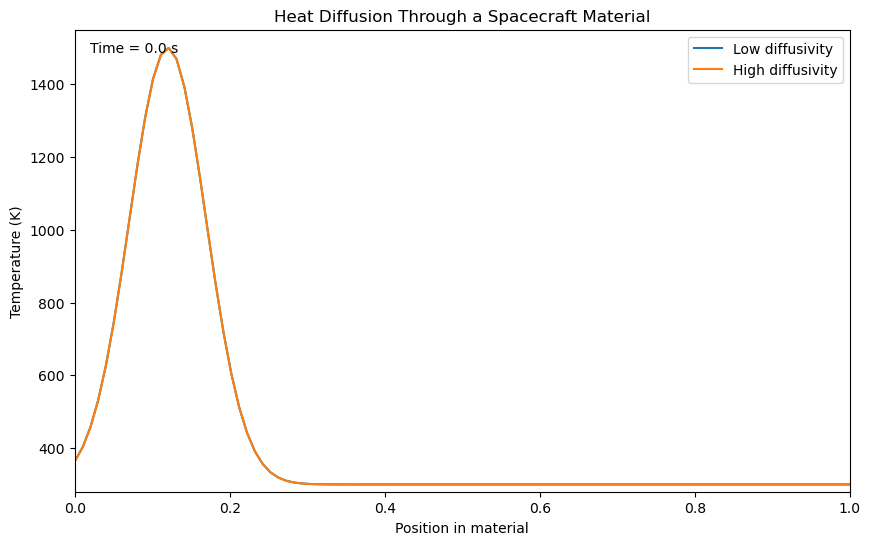

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

# -----------------------------
# Parameters
# -----------------------------
L = 1.0                 # thickness of material
nx = 100                # number of spatial grid points
dx = L / (nx - 1)
x = np.linspace(0, L, nx)

t_final = 120          # total simulation time (seconds)

# Two materials
alpha_low = 2e-6       # low thermal diffusivity
alpha_high = 1.2e-4    # high thermal diffusivity

# Stability condition for explicit method:
# r = alpha*dt/dx^2 <= 1/2
alpha_max = max(alpha_low, alpha_high)
dt = 0.4 * dx**2 / alpha_max
nt = int(t_final / dt)

# Initial temperature
T_initial = 300.0      # Kelvin

# Hotspot near outer surface
def initial_profile(x):
    return T_initial + 1200 * np.exp(-((x - 0.12) / 0.07)**2)

# -----------------------------
# Boundary conditions
# -----------------------------
# Left boundary: insulated
# Right boundary: insulated
# This keeps the demo simple and shows heat spreading clearly

def step_heat(u, alpha):
    r = alpha * dt / dx**2
    u_new = u.copy()

    # interior points
    for i in range(1, nx - 1):
        u_new[i] = u[i] + r * (u[i+1] - 2*u[i] + u[i-1])

    # insulated boundaries: du/dx = 0
    u_new[0] = u_new[1]
    u_new[-1] = u_new[-2]

    return u_new

# -----------------------------
# Initialize solutions
# -----------------------------
u_low = initial_profile(x)
u_high = initial_profile(x)

history_low = [u_low.copy()]
history_high = [u_high.copy()]
times = [0]

for n in range(nt):
    u_low = step_heat(u_low, alpha_low)
    u_high = step_heat(u_high, alpha_high)

    # save every few steps so animation is smoother and lighter
    if n % 20 == 0:
        history_low.append(u_low.copy())
        history_high.append(u_high.copy())
        times.append((n + 1) * dt)

history_low = np.array(history_low)
history_high = np.array(history_high)

# -----------------------------
# Plot animation
# -----------------------------
fig, ax = plt.subplots(figsize=(10, 6))

line1, = ax.plot(x, history_low[0], label='Low diffusivity')
line2, = ax.plot(x, history_high[0], label='High diffusivity')

ax.set_xlim(0, L)
ax.set_ylim(T_initial - 20, np.max(history_low[0]) + 50)
ax.set_xlabel("Position in material")
ax.set_ylabel("Temperature (K)")
ax.set_title("Heat Diffusion Through a Spacecraft Material")
ax.legend()

time_text = ax.text(0.02, 0.95, "", transform=ax.transAxes)

def update(frame):
    line1.set_ydata(history_low[frame])
    line2.set_ydata(history_high[frame])
    time_text.set_text(f"Time = {times[frame]:.1f} s")
    return line1, line2, time_text

ani = FuncAnimation(fig, update, frames=len(times), interval=120, blit=True)
plt.show()

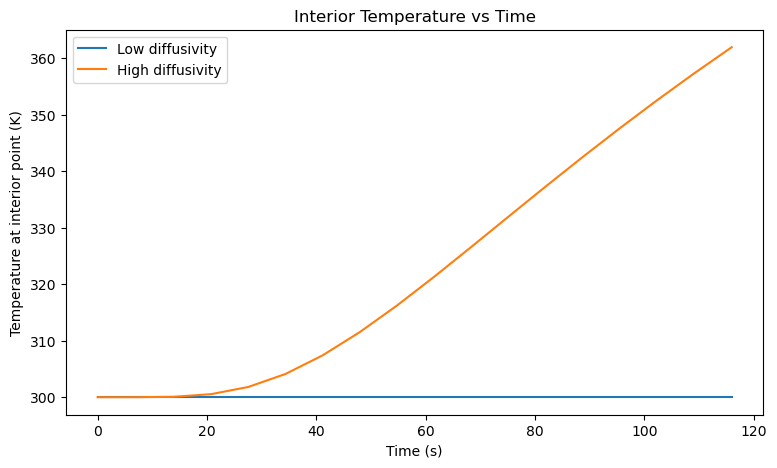

In [17]:
import matplotlib.pyplot as plt

interior_index = int(0.45 * (nx - 1))

plt.figure(figsize=(9, 5))
plt.plot(times, history_low[:, interior_index], label="Low diffusivity")
plt.plot(times, history_high[:, interior_index], label="High diffusivity")
plt.xlabel("Time (s)")
plt.ylabel("Temperature at interior point (K)")
plt.title("Interior Temperature vs Time")
plt.legend()
plt.show()

In [19]:
# 🚀 Spacecraft Wall Demo: The Thermal Diffusivity Tradeoff

## Problem Setup

**Scenario:** A spacecraft wall is hit with intense external heating. We need to protect the interior.

- **Left boundary (x=0):** Outer surface exposed to heating (hotspot at $t=0$)
- **Right boundary (x=L):** Inner surface we want to protect
- **Material property:** Thermal diffusivity $\alpha$ controls how fast heat spreads

**The Key Question:** Does a material that spreads heat quickly protect the interior better?


SyntaxError: invalid syntax (2833844085.py, line 5)

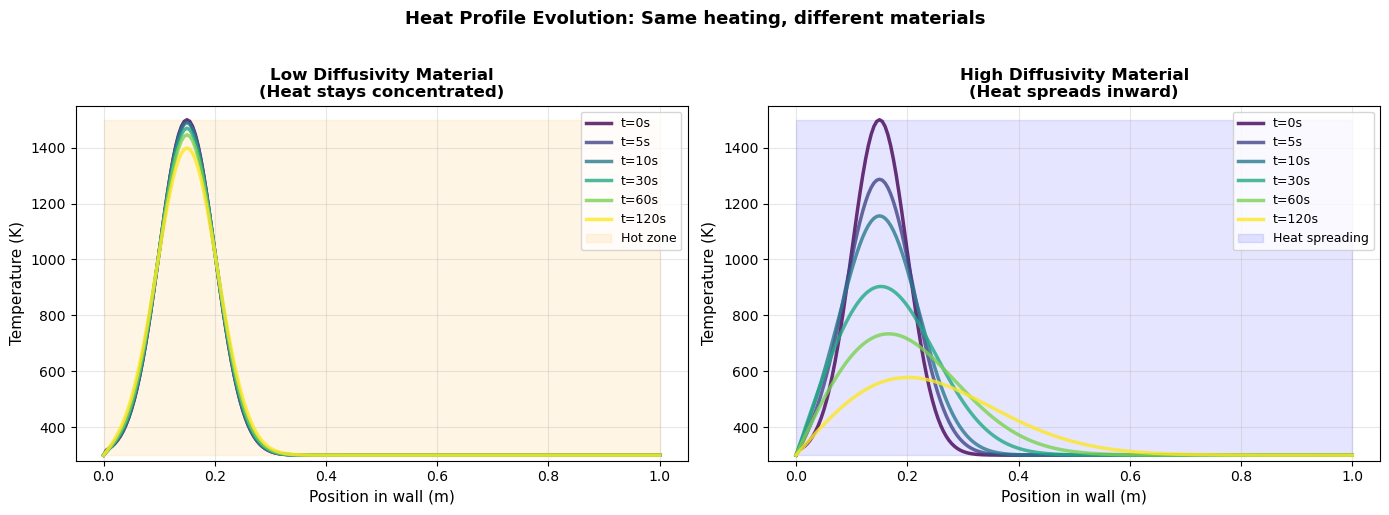

✓ Notice: Low diffusivity keeps heat concentrated near the surface.
✓ Notice: High diffusivity spreads heat deeper but reduces peak temperature.


In [ ]:
# --- Part 1: Temperature Profile Comparison ---
# This shows HOW the heat spreads differently in each material

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Select time steps to visualize: early, middle, late
viz_times = [0.0, 5.0, 10.0, 30.0, 60.0, 120.0]
colors = plt.cm.viridis(np.linspace(0, 1, len(viz_times)))

# Low diffusivity: heat stays concentrated near surface
for i, t_plot in enumerate(viz_times):
    axes[0].plot(low_case['x'], low_case['snapshots'][t_plot], 
                linewidth=2.5, color=colors[i], label=f't={t_plot:.0f}s', alpha=0.8)

axes[0].fill_between(low_case['x'], 300, 1500, alpha=0.1, color='orange', label='Hot zone')
axes[0].set_title('Low Diffusivity Material\n(Heat stays concentrated)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Position in wall (m)', fontsize=11)
axes[0].set_ylabel('Temperature (K)', fontsize=11)
axes[0].set_ylim(280, 1550)
axes[0].grid(alpha=0.3)
axes[0].legend(loc='upper right', fontsize=9)

# High diffusivity: heat spreads quickly inward
for i, t_plot in enumerate(viz_times):
    axes[1].plot(high_case['x'], high_case['snapshots'][t_plot], 
                linewidth=2.5, color=colors[i], label=f't={t_plot:.0f}s', alpha=0.8)

axes[1].fill_between(high_case['x'], 300, 1500, alpha=0.1, color='blue', label='Heat spreading')
axes[1].set_title('High Diffusivity Material\n(Heat spreads inward)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Position in wall (m)', fontsize=11)
axes[1].set_ylabel('Temperature (K)', fontsize=11)
axes[1].set_ylim(280, 1550)
axes[1].grid(alpha=0.3)
axes[1].legend(loc='upper right', fontsize=9)

plt.suptitle('Heat Profile Evolution: Same heating, different materials', 
            fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("✓ Notice: Low diffusivity keeps heat concentrated near the surface.")
print("✓ Notice: High diffusivity spreads heat deeper but reduces peak temperature.")


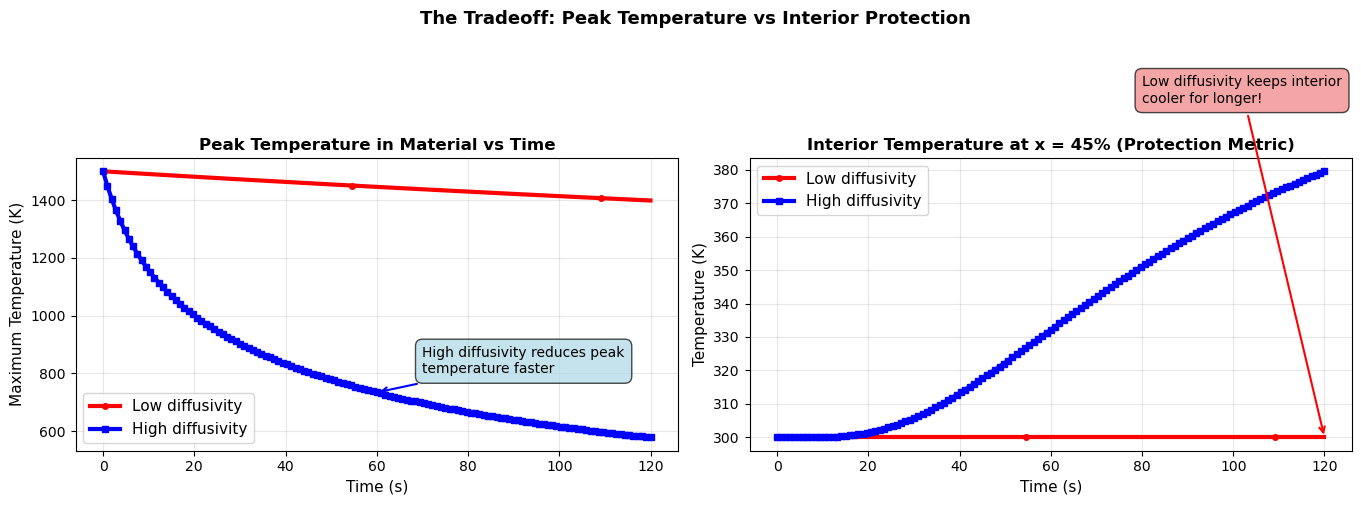


ENGINEERING INSIGHT: The Thermal Diffusivity Tradeoff

After 120 seconds of heating:

Peak Temperature (degrees cooler):
  • High diffusivity: 578 K
  • Low diffusivity:  1399 K
  → Difference: 821 K
    (High diffusivity wins for surface protection)

Interior Temperature at x = 45%:
  • Low diffusivity:  300 K
  • High diffusivity: 379 K
  → Difference: 79 K warmer
    (Low diffusivity wins for interior protection!)

✓ This is the fundamental engineering tradeoff:
  - High α spreads heat → lower peak temperatures (good for structure)
  - Low α resists spreading → interior stays cooler (good for payload)


In [ ]:
# --- Part 2: THE KEY METRIC - Interior Temperature Over Time ---
# This directly answers: "Which material better protects the interior of the spacecraft?"

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Peak temperature in the material
axes[0].plot(low_case['times'], low_case['max_temp'], linewidth=3, 
            label='Low diffusivity', color='red', marker='o', markersize=4, markevery=10)
axes[0].plot(high_case['times'], high_case['max_temp'], linewidth=3, 
            label='High diffusivity', color='blue', marker='s', markersize=4, markevery=10)
axes[0].set_title('Peak Temperature in Material vs Time', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Time (s)', fontsize=11)
axes[0].set_ylabel('Maximum Temperature (K)', fontsize=11)
axes[0].grid(alpha=0.3)
axes[0].legend(fontsize=11)
axes[0].annotate('High diffusivity reduces peak\ntemperature faster', 
                xy=(60, high_case['max_temp'][int(len(high_case['times'])*0.5)]), 
                xytext=(70, 800), fontsize=10, ha='left',
                bbox=dict(boxstyle='round,pad=0.5', facecolor='lightblue', alpha=0.7),
                arrowprops=dict(arrowstyle='->', color='blue', lw=1.5))

# Plot 2: Interior point temperature (the protection metric)
probe_x = low_case['probe_x']
axes[1].plot(low_case['times'], low_case['probe_temp'], linewidth=3, 
            label='Low diffusivity', color='red', marker='o', markersize=4, markevery=10)
axes[1].plot(high_case['times'], high_case['probe_temp'], linewidth=3, 
            label='High diffusivity', color='blue', marker='s', markersize=4, markevery=10)
axes[1].set_title(f'Interior Temperature at x = {probe_x:.0%} (Protection Metric)', 
                 fontsize=12, fontweight='bold')
axes[1].set_xlabel('Time (s)', fontsize=11)
axes[1].set_ylabel('Temperature (K)', fontsize=11)
axes[1].grid(alpha=0.3)
axes[1].legend(fontsize=11)
axes[1].annotate('Low diffusivity keeps interior\ncooler for longer!', 
                xy=(120, low_case['probe_temp'][-1]), 
                xytext=(80, low_case['probe_temp'][-1]+100), fontsize=10, ha='left',
                bbox=dict(boxstyle='round,pad=0.5', facecolor='lightcoral', alpha=0.7),
                arrowprops=dict(arrowstyle='->', color='red', lw=1.5))

plt.suptitle('The Tradeoff: Peak Temperature vs Interior Protection', 
            fontsize=13, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("ENGINEERING INSIGHT: The Thermal Diffusivity Tradeoff")
print("="*70)
print(f"\nAfter {t_final} seconds of heating:\n")
print(f"Peak Temperature (degrees cooler):")
print(f"  • High diffusivity: {high_case['max_temp'][-1]:.0f} K")
print(f"  • Low diffusivity:  {low_case['max_temp'][-1]:.0f} K")
print(f"  → Difference: {low_case['max_temp'][-1] - high_case['max_temp'][-1]:.0f} K")
print(f"    (High diffusivity wins for surface protection)")

print(f"\nInterior Temperature at x = {probe_x:.0%}:")
print(f"  • Low diffusivity:  {low_case['probe_temp'][-1]:.0f} K")
print(f"  • High diffusivity: {high_case['probe_temp'][-1]:.0f} K")
print(f"  → Difference: {high_case['probe_temp'][-1] - low_case['probe_temp'][-1]:.0f} K warmer")
print(f"    (Low diffusivity wins for interior protection!)")

print("\n✓ This is the fundamental engineering tradeoff:")
print("  - High α spreads heat → lower peak temperatures (good for structure)")
print("  - Low α resists spreading → interior stays cooler (good for payload)")
print("="*70)


c:\Users\ereno\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128997 (\N{LARGE RED SQUARE}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\ereno\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128998 (\N{LARGE BLUE SQUARE}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)


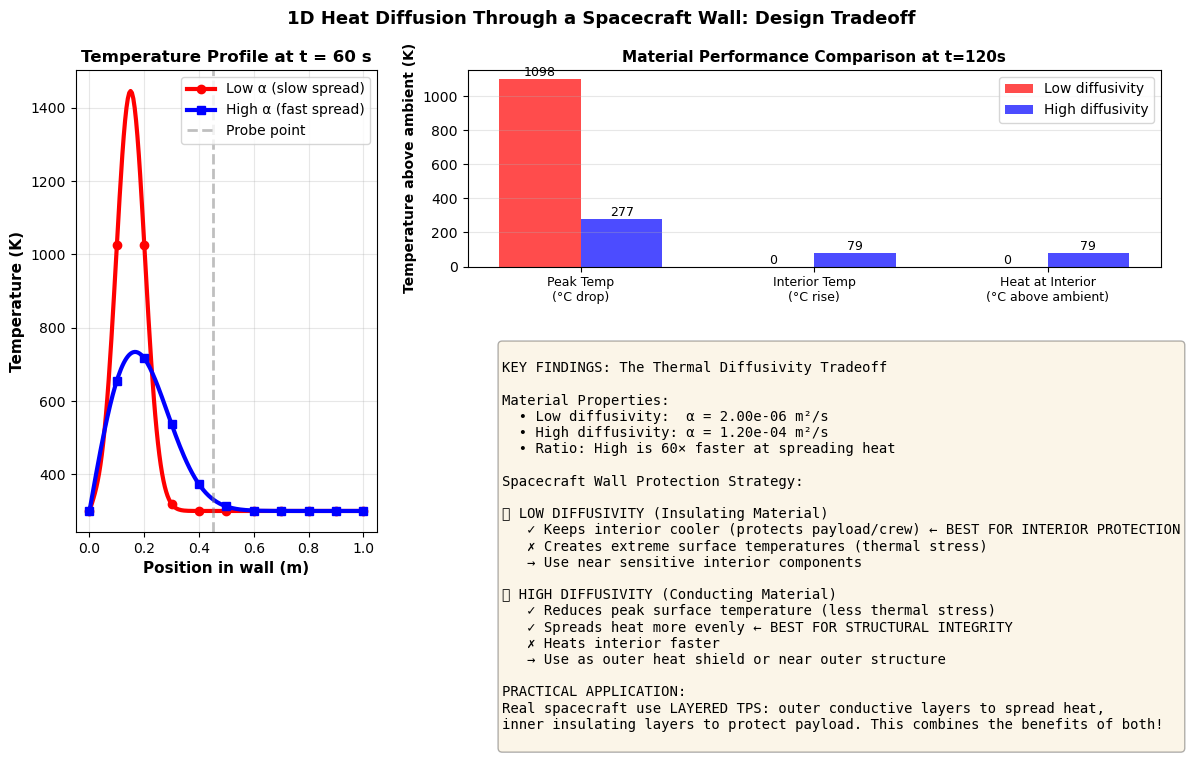


🚀 CLASSROOM MESSAGE:
----------------------------------------------------------------------
Same heating, same wall thickness, but DIFFERENT MATERIAL PROPERTIES.

One material spreads heat quickly → outer surface stays cooler
Other material resists heat spreading → interior stays cooler

Which one is 'better'? It depends on your design goal!
Real spacecraft combine both for optimized thermal protection.
----------------------------------------------------------------------


In [ ]:
# --- Part 3: Material Comparison Dashboard ---
# Summary visualization for the classroom

fig = plt.figure(figsize=(14, 6))
gs = fig.add_gridspec(2, 3, hspace=0.35, wspace=0.3)

# Large left plot: Snapshot at t=60s showing the "middle of the story"
ax_main = fig.add_subplot(gs[:, 0])
t_snapshot = 60.0
ax_main.plot(low_case['x'], low_case['snapshots'][t_snapshot], linewidth=3, 
            color='red', label='Low α (slow spread)', marker='o', markersize=6, markevery=20)
ax_main.plot(high_case['x'], high_case['snapshots'][t_snapshot], linewidth=3, 
            color='blue', label='High α (fast spread)', marker='s', markersize=6, markevery=20)
ax_main.axvline(high_case['probe_x'], color='gray', linestyle='--', linewidth=2, alpha=0.5, label='Probe point')
ax_main.set_xlabel('Position in wall (m)', fontsize=11, fontweight='bold')
ax_main.set_ylabel('Temperature (K)', fontsize=11, fontweight='bold')
ax_main.set_title(f'Temperature Profile at t = {t_snapshot:.0f} s', fontsize=12, fontweight='bold')
ax_main.grid(alpha=0.3)
ax_main.legend(fontsize=10, loc='upper right')

# Top right: Quantitative metric 1
ax1 = fig.add_subplot(gs[0, 1:])
metrics = ['Peak Temp\n(°C drop)', 'Interior Temp\n(°C rise)', 'Heat at Interior\n(°C above ambient)']
low_vals = [
    low_case['max_temp'][-1] - 300,
    low_case['probe_temp'][-1] - 300,
    low_case['probe_temp'][-1] - 300
]
high_vals = [
    high_case['max_temp'][-1] - 300,
    high_case['probe_temp'][-1] - 300,
    high_case['probe_temp'][-1] - 300
]

x_pos = np.arange(len(metrics))
width = 0.35

bars1 = ax1.bar(x_pos - width/2, low_vals, width, label='Low diffusivity', color='red', alpha=0.7)
bars2 = ax1.bar(x_pos + width/2, high_vals, width, label='High diffusivity', color='blue', alpha=0.7)

ax1.set_ylabel('Temperature above ambient (K)', fontsize=10, fontweight='bold')
ax1.set_title('Material Performance Comparison at t=120s', fontsize=11, fontweight='bold')
ax1.set_xticks(x_pos)
ax1.set_xticklabels(metrics, fontsize=9)
ax1.legend(fontsize=10)
ax1.grid(alpha=0.3, axis='y')

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height)}', ha='center', va='bottom', fontsize=9)

# Bottom right: Material properties and key differences
ax2 = fig.add_subplot(gs[1, 1:])
ax2.axis('off')

summary_text = f"""
KEY FINDINGS: The Thermal Diffusivity Tradeoff

Material Properties:
  • Low diffusivity:  α = {alpha_low:.2e} m²/s
  • High diffusivity: α = {alpha_high:.2e} m²/s
  • Ratio: High is {alpha_high/alpha_low:.0f}× faster at spreading heat

Spacecraft Wall Protection Strategy:

🟥 LOW DIFFUSIVITY (Insulating Material)
   ✓ Keeps interior cooler (protects payload/crew) ← BEST FOR INTERIOR PROTECTION
   ✗ Creates extreme surface temperatures (thermal stress)
   → Use near sensitive interior components

🟦 HIGH DIFFUSIVITY (Conducting Material)  
   ✓ Reduces peak surface temperature (less thermal stress)
   ✓ Spreads heat more evenly ← BEST FOR STRUCTURAL INTEGRITY
   ✗ Heats interior faster
   → Use as outer heat shield or near outer structure

PRACTICAL APPLICATION:
Real spacecraft use LAYERED TPS: outer conductive layers to spread heat,
inner insulating layers to protect payload. This combines the benefits of both!
"""

ax2.text(0.05, 0.95, summary_text, transform=ax2.transAxes, fontsize=10,
        verticalalignment='top', fontfamily='monospace',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))

plt.suptitle('1D Heat Diffusion Through a Spacecraft Wall: Design Tradeoff', 
            fontsize=13, fontweight='bold', y=0.98)
plt.show()

print("\n🚀 CLASSROOM MESSAGE:")
print("-" * 70)
print("Same heating, same wall thickness, but DIFFERENT MATERIAL PROPERTIES.")
print("\nOne material spreads heat quickly → outer surface stays cooler")
print("Other material resists heat spreading → interior stays cooler")
print("\nWhich one is 'better'? It depends on your design goal!")
print("Real spacecraft combine both for optimized thermal protection.")
print("-" * 70)


## 🎮 Interactive Exploration: What happens when you change the parameters?

Run the simulation cells above first. Then, modify these parameters and re-run to see how it affects the results:

**What to try:**
1. **Change material thickness (L):** Edit `L = 1.0` in the `simulate_hotspot_diffusion` function
   - Thicker walls → heat takes longer to penetrate (good for protection)
   - Thinner walls → heat reaches interior faster

2. **Change heating intensity:** Edit the `1200.0` in the initial hotspot profile
   - Stronger heating → higher peak temperatures but same relative difference

3. **Add intermediate diffusivity:** Create `alpha_medium = 1e-5` and run another simulation
   - Explore the spectrum of behavior between low and high

4. **Change simulation time:** Modify `t_final = 120.0`
   - Short times → see early heat propagation
   - Long times → see steady-state behavior

**Key insight:** The ratio of peak temperatures and interior temperatures will change, but the fundamental **tradeoff remains**: fast-spreading materials protect the exterior, slow-spreading materials protect the interior.
